In [1]:
import geopandas as gpd
import xarray as xr
import numpy as np
import rioxarray as rxr
import os
from math import e
import matplotlib.pyplot as plt
import pandas as pd

Index(['BASIN_ID', 'Shape_Leng', 'Shape_Area', 'Segment_ID', 'Acc_Cl',
       'Perim_Buff', 'InsidePeri', 'OutsidePer', 'Fire_ID', 'Fire_Segme',
       'L_X1', 'L_X2', 'L_X3', 'V_X1', 'V_X2', 'Shape_Le_1', 'R', 'V_X3', 'X',
       'ExpX', 'P', 'PCl', 'PCl_Legend', 'LnV', 'Volume', 'VolMin', 'VolMax',
       'VolCl', 'VolCl_Lege', 'CombHaz', 'CombHazCl', 'CombHazCl_', 'area',
       'Field', 'ROC', 'nearest_st', 'distance_t', 'RI_index', 'RI',
       'Mean_dNBR', 'Med_dNBR', 'PF_dNBR', 'M1P_Mean', 'M1P_Med', 'M1p_PF',
       'M1M_dNBR', 'M1Md_dNBR', 'M1PF_dNBR', 'M1Q1_dNBR', 'HM1M_dNBR',
       'HM1Md_dNBR', 'HM1PF_dNBR', 'HM1Q1_dNBR', 'OHM1M_dNBR', 'OHM1Md_dNB',
       'OHM1PF_dNB', 'OHM1Q1_dNB', 'geometry'],
      dtype='object')

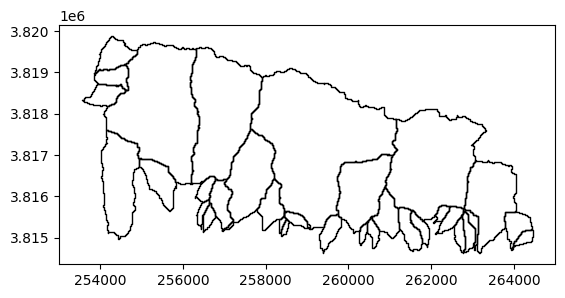

In [5]:
# import the new MvH shapefile

MvH_shp = gpd.read_file(r'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/MontecitoBasins_dNBR_RI.shp')
MvH_shp.plot(edgecolor='black', facecolor='none')
MvH_shp.columns

In [14]:
# Create M1 probability model, using the appropriate dNBR and RI values
def MvH_M1(dnbr, Value):
    
    # Coefficients for Southern California
    b = -3.63
    b_1 = 0.41
    b_2 = 0.67
    b_3 = 0.7
    
    x_1 = dnbr['L_X1']
    x_3 = dnbr['L_X3']
    x_2 = dnbr[f'{Value}']
    RI = dnbr['RI']
    lnx =  b + (b_1 * x_1 * RI) + (b_2 * x_2 * RI) + (b_3 * x_3 * RI)
    prob = (e ** lnx) / (1.0 + e ** lnx)
    return {
        'BASIN_ID': basin_id,
        'RI': RI *4,
        'M1P': prob
    }

In [ ]:
# Create functional probability model, using the appropriate dNBR and RI values
def MvH_M1_all(dnbr, Value):
    
    # Coefficients for Southern California
    b = -3.63
    b_1 = 0.41
    b_2 = 0.67
    b_3 = 0.7
    
    x_1 = dnbr['L_X1']
    x_3 = dnbr['L_X3']
    x_2 = dnbr[f'{Value}']
    RI = dnbr['RI']
    lnx =  b + (b_1 * x_1 * RI) + (b_2 * x_2 * RI) + (b_3 * x_3 * RI)
    prob = (e ** lnx) / (1.0 + e ** lnx)
    return {
        'BASIN_ID': basin_id,
        'RI': RI *4,
        'M1P': prob
    }

In [21]:
test_results = []
for basin_id in MvH_shp['BASIN_ID'].unique():
    basin_data = MvH_shp[MvH_shp['BASIN_ID'] == basin_id].iloc[0]
    test = MvH_M1(basin_data, 'M1M_dNBR')
    test_results.append(test)


In [22]:
testdf = pd.DataFrame(test_results)
testdf

,BASIN_ID,RI,M1P
0,12057,78.24,0.998743
1,13281,78.24,0.910854
2,19777,104.64,0.999584
3,20254,74.16,0.998125
4,20308,104.64,0.999988
5,21634,74.16,0.993195
6,17346,78.24,0.999881
7,17347,78.24,0.999993
8,17987,74.16,0.999938
9,19165,104.64,0.999999


In [29]:
model_cols = [
    'M1M_dNBR', 'M1Md_dNBR', 'M1PF_dNBR', 'M1Q1_dNBR',
    'HM1M_dNBR', 'HM1Md_dNBR', 'HM1PF_dNBR', 'HM1Q1_dNBR',
    'OHM1M_dNBR', 'OHM1Md_dNB', 'OHM1PF_dNB', 'OHM1Q1_dNB'
]

In [30]:
# one row per basin
basin_df = MvH_shp.drop_duplicates(subset='BASIN_ID').copy()

# Start output dataframe with IDs
prob_df = basin_df[['BASIN_ID']].copy()

In [31]:
b = -3.63
b_1 = 0.41
b_2 = 0.67
b_3 = 0.70

x1 = basin_df['L_X1']
x3 = basin_df['L_X3']
ri = basin_df['RI']


In [32]:

for col in model_cols:

    lnx = b + (b_1 * x1 * ri) + (b_2 * basin_df[col] * ri) + (b_3 * x3 * ri)
    prob = np.exp(lnx) / (1 + np.exp(lnx))

    clean = col.replace('_dNBR','').replace('_dNB','')
    prob_df[f'{clean}_prob'] = prob

prob_df

,BASIN_ID,M1M_prob,M1Md_prob,M1PF_prob,M1Q1_prob,HM1M_prob,HM1Md_prob,HM1PF_prob,HM1Q1_prob,OHM1M_prob,OHM1Md_prob,OHM1PF_prob,OHM1Q1_prob
0,12057,0.998743,0.999379,0.999738,0.988967,0.999664,0.999818,0.999915,0.995891,0.999761,0.999920,0.999913,0.995037
1,13281,0.910854,0.651211,0.472421,0.419910,0.955901,0.774203,0.602017,0.512938,0.951872,0.785423,0.603456,0.339187
2,19777,0.999584,0.999735,0.999809,0.998864,0.999862,0.999924,0.999936,0.999615,0.999886,0.999946,0.999936,0.999396
3,20254,0.998125,0.999110,0.999434,0.991657,0.998887,0.999524,0.999720,0.994900,0.999217,0.999752,0.999720,0.996129
4,20308,0.999988,0.999998,0.999999,0.999391,0.999993,0.999999,1.000000,0.999449,0.999996,1.000000,1.000000,0.999459
5,21634,0.993195,0.994789,0.999134,0.945763,0.993829,0.995601,0.999461,0.941958,0.993860,0.996592,0.999459,0.834334
6,17346,0.999881,0.999965,0.999983,0.998112,0.999955,0.999987,0.999995,0.998875,0.999956,0.999990,0.999995,0.997543
7,17347,0.999993,0.999995,0.999996,0.999982,0.999998,0.999999,0.999999,0.999994,0.999999,0.999999,0.999999,0.999995
8,17987,0.999938,0.999948,0.999954,0.999890,0.999983,0.999985,0.999985,0.999967,0.999988,0.999992,0.999985,0.999974
9,19165,0.999999,1.000000,1.000000,0.999995,1.000000,1.000000,1.000000,0.999997,1.000000,1.000000,1.000000,0.999995


In [33]:
MvH_shp = MvH_shp.merge(prob_df, on="BASIN_ID")

In [35]:
MvH_shp.columns

Index(['BASIN_ID', 'Shape_Leng', 'Shape_Area', 'Segment_ID', 'Acc_Cl',
       'Perim_Buff', 'InsidePeri', 'OutsidePer', 'Fire_ID', 'Fire_Segme',
       'L_X1', 'L_X2', 'L_X3', 'V_X1', 'V_X2', 'Shape_Le_1', 'R', 'V_X3', 'X',
       'ExpX', 'P', 'PCl', 'PCl_Legend', 'LnV', 'Volume', 'VolMin', 'VolMax',
       'VolCl', 'VolCl_Lege', 'CombHaz', 'CombHazCl', 'CombHazCl_', 'area',
       'Field', 'ROC', 'nearest_st', 'distance_t', 'RI_index', 'RI',
       'Mean_dNBR', 'Med_dNBR', 'PF_dNBR', 'M1P_Mean', 'M1P_Med', 'M1p_PF',
       'M1M_dNBR', 'M1Md_dNBR', 'M1PF_dNBR', 'M1Q1_dNBR', 'HM1M_dNBR',
       'HM1Md_dNBR', 'HM1PF_dNBR', 'HM1Q1_dNBR', 'OHM1M_dNBR', 'OHM1Md_dNB',
       'OHM1PF_dNB', 'OHM1Q1_dNB', 'geometry', 'M1M_prob', 'M1Md_prob',
       'M1PF_prob', 'M1Q1_prob', 'HM1M_prob', 'HM1Md_prob', 'HM1PF_prob',
       'HM1Q1_prob', 'OHM1M_prob', 'OHM1Md_prob', 'OHM1PF_prob',
       'OHM1Q1_prob'],
      dtype='object')

In [ ]:
# I forgot I need to add the old inventory values for initiation, so I can do a proper ROC analysis
ROC_m1 = gpd.read_file(r'/Volumes/PhD/imagery/masters/ROC/M1_CT_ROC.shp')
ROC_m1.columns

Index(['BASIN_ID', 'Shape_Leng', 'Shape_Area', 'Segment_ID', 'Acc_Cl',
       'Perim_Buff', 'InsidePeri', 'OutsidePer', 'Fire_ID', 'Fire_Segme',
       'L_X1', 'L_X2', 'L_X3', 'V_X1', 'V_X2', 'Shape_Le_1', 'R', 'V_X3', 'X',
       'ExpX', 'P', 'PCl', 'PCl_Legend', 'LnV', 'Volume', 'VolMin', 'VolMax',
       'VolCl', 'VolCl_Lege', 'CombHaz', 'CombHazCl', 'CombHazCl_', 'area',
       'Field', 'ROC', 'nearest_st', 'distance_t', 'RI_index', 'RI',
       'Mean_dNBR', 'Med_dNBR', 'PF_dNBR', 'M1P_Mean', 'M1P_Med', 'M1p_PF',
       'geometry'],
      dtype='object')

In [45]:
# Subset to just the columns I need for the ROC analysis, which is BASIN_ID and Field, which is the binary landslide initiation variable.

roc_df = ROC_m1[['BASIN_ID', 'Field']].copy()
roc_df

,BASIN_ID,Field
0,17499,1
1,3115,4
2,3589,4
3,5683,4
4,5920,4
...,...,...
732,15065,0
733,35852,0
734,36553,0
735,36955,0


In [47]:
# Subset to BASIN_ID values in MvH_shp, rename Field to Old_ROC
roc_df = roc_df[roc_df['BASIN_ID'].isin(MvH_shp['BASIN_ID'])]
roc_df = roc_df.rename(columns={'Field': 'Old_ROC'})
roc_df

,BASIN_ID,Old_ROC
17,12057,4
24,13281,4
30,19777,4
32,20254,4
33,20308,4
34,21634,4
46,17346,2
47,17347,2
48,17987,2
49,19165,2


In [48]:
# Merge the old ROC values into the MvH_shp dataframe
MvH_shp = MvH_shp.merge(roc_df, on='BASIN_ID')
MvH_shp.columns

Index(['BASIN_ID', 'Shape_Leng', 'Shape_Area', 'Segment_ID', 'Acc_Cl',
       'Perim_Buff', 'InsidePeri', 'OutsidePer', 'Fire_ID', 'Fire_Segme',
       'L_X1', 'L_X2', 'L_X3', 'V_X1', 'V_X2', 'Shape_Le_1', 'R', 'V_X3', 'X',
       'ExpX', 'P', 'PCl', 'PCl_Legend', 'LnV', 'Volume', 'VolMin', 'VolMax',
       'VolCl', 'VolCl_Lege', 'CombHaz', 'CombHazCl', 'CombHazCl_', 'area',
       'Field', 'ROC', 'nearest_st', 'distance_t', 'RI_index', 'RI',
       'Mean_dNBR', 'Med_dNBR', 'PF_dNBR', 'M1P_Mean', 'M1P_Med', 'M1p_PF',
       'M1M_dNBR', 'M1Md_dNBR', 'M1PF_dNBR', 'M1Q1_dNBR', 'HM1M_dNBR',
       'HM1Md_dNBR', 'HM1PF_dNBR', 'HM1Q1_dNBR', 'OHM1M_dNBR', 'OHM1Md_dNB',
       'OHM1PF_dNB', 'OHM1Q1_dNB', 'geometry', 'M1M_prob', 'M1Md_prob',
       'M1PF_prob', 'M1Q1_prob', 'HM1M_prob', 'HM1Md_prob', 'HM1PF_prob',
       'HM1Q1_prob', 'OHM1M_prob', 'OHM1Md_prob', 'OHM1PF_prob', 'OHM1Q1_prob',
       'Old_ROC'],
      dtype='object')

In [49]:
MvH_shp.to_file(r'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/MontecitoBasins_Prob.shp', driver='ESRI Shapefile')

/var/folders/mm/sjj0b1k91z39pkxfzn0rj_1h0000gn/T/ipykernel_56016/4200510854.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  MvH_shp.to_file(r'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/MontecitoBasins_Prob.shp', driver='ESRI Shapefile')
/Users/samueltaylor/Documents/GitHub/PHA_burn_severity/.venv/lib/python3.9/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'OHM1Md_prob' to 'OHM1Md_pro'
  ogr_write(
/Users/samueltaylor/Documents/GitHub/PHA_burn_severity/.venv/lib/python3.9/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'OHM1PF_prob' to 'OHM1PF_pro'
  ogr_write(
/Users/samueltaylor/Documents/GitHub/PHA_burn_severity/.venv/lib/python3.9/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'OHM1Q1_prob' to 'OHM1Q1_pro'
  ogr_write(


<Axes: >

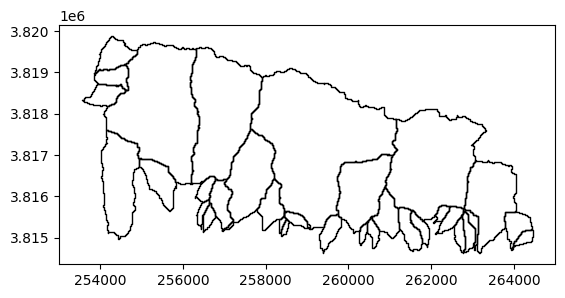